In [47]:
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
df = pd.read_csv("small_room_data.csv")

df.head()

,hour_of_day,temperature_c,humidity_pct,light_lux,occupancy_count,co2_ppm,power_consumption_w
0,0,26.34,65.23,16.7,12,1052.8,1192.63
1,0,29.15,44.51,18.5,3,618.0,857.01
2,0,29.71,65.79,59.1,14,1150.3,1244.43
3,0,30.36,70.60,10.4,2,662.9,708.83
4,0,25.64,85.96,0.6,1,663.9,718.40


In [49]:
X = df[['hour_of_day', 'temperature_c', 'humidity_pct', 'light_lux', 'occupancy_count', 'co2_ppm']]
y = df['power_consumption_w']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 240
Testing set size: 60


In [51]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.22,17.3 , 2.15, 0.02,31.62, 0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['hour_of_day','temperature_c','humidity_pct','light_lux', 'occupancy_count','co2_ppm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,44.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [52]:
print("Slope coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Slope coefficients: [2.20765954e-01 1.72997051e+01 2.14975702e+00 1.74372387e-02
 3.16164746e+01 1.11906296e-01]
Intercept: 44.13261839342886


In [53]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": abs(y_test - y_pred)
})

results.head()

,Actual,Predicted,Error
203,1365.23,1207.228671,158.001329
266,1065.22,1039.354654,25.865346
152,1126.16,1271.267829,145.107829
9,785.66,790.541943,4.881943
233,1148.23,1075.453641,72.776359


In [54]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 45.91900930368862
Mean Squared Error (MSE): 3390.797331685293
Root Mean Squared Error (RMSE): 58.230553249005744
R-squared (R2): 0.9068292108762042


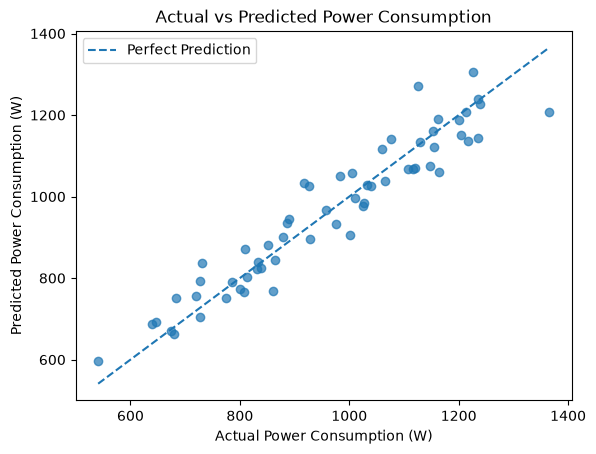

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Power Consumption (W)")
plt.ylabel("Predicted Power Consumption (W)")
plt.title("Actual vs Predicted Power Consumption")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.legend()
plt.show()

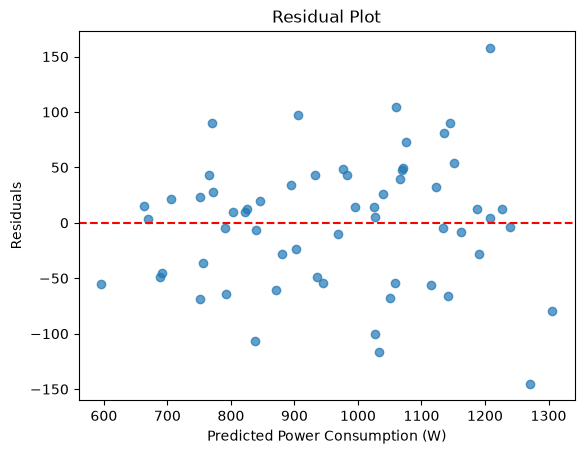

In [56]:
residuals = y_test - y_pred

plt.plot(y_pred, residuals, 'o', alpha=0.7)
plt.xlabel("Predicted Power Consumption (W)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()